In [2]:
import numpy as np
import networkx as nx
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from node2vec import Node2Vec
from scipy import stats
import copy

# Weighted SBM

In [3]:
np.random.seed(0)
block_size = 100
num_blocks = 3
n = block_size * num_blocks

p = 1.5*n**(-0.3)
r = 0.15*n**(-0.3)
probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

intra_mean = 20
inter_mean = 5
means = np.eye(num_blocks) * intra_mean + (1 - np.eye(num_blocks)) * inter_mean

print(f"Intra prob: {p}")
print(f"Inter prob: {r}")
print(f"Intra mean: {intra_mean}")
print(f"Inter mean: {inter_mean}")

Intra prob: 0.2709910094026613
Inter prob: 0.02709910094026613
Intra mean: 20
Inter mean: 5


In [4]:
def get_poisson_SBM(block_size, num_blocks, probs, means):
    """
    Generate a weighted SBM with Poisson distributed weights
    """
    n = block_size * num_blocks
    adjacency_matrix_output = np.zeros((n, n))

    for i in range(n):
        for j in range(i+1, n):
            if np.random.rand() < probs[i//block_size, j//block_size]:
                adjacency_matrix_output[i, j] = np.random.poisson(lam=means[i//block_size, j//block_size])
                adjacency_matrix_output[j, i] = adjacency_matrix_output[i, j]
    
    return nx.from_numpy_array(adjacency_matrix_output)

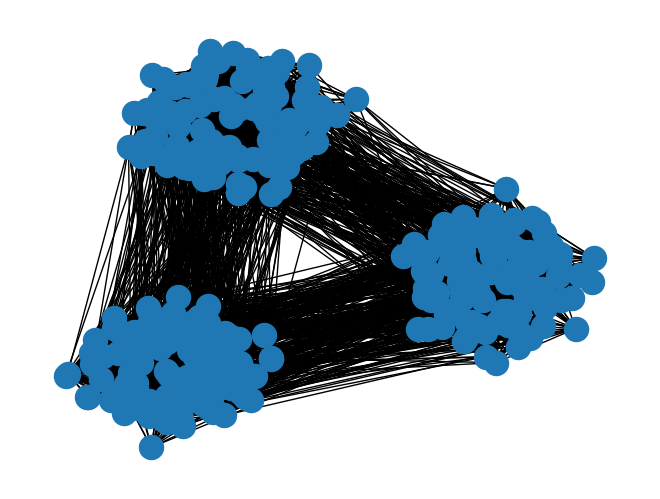

In [5]:
G = get_poisson_SBM(block_size, num_blocks, probs, means)
nx.draw(G)

# DP Algorithms

In [6]:
def edge_flip(A, epsilon):
    """
    Definition 5 from: https://arxiv.org/pdf/2105.12615


    """
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))
            if x == 1:
                # Flip the edge
                # If the edge is 0, flip it to 1 (weight 1)
                # If the edge is weighted, flip it to 0
                A_perturbed[i,j] = 1 - int(A[i,j] > 0)
                A_perturbed[j,i] = 1 - int(A[i,j] > 0)
            else:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
    
    return A_perturbed

In [7]:
def laplace_edge_weight(A, epsilon, delta, means):
    """
    """
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            if A[i,j] > 0:
                sensitivity = stats.poisson.ppf(1-delta, mu=means[i//block_size, j//block_size])
                A_perturbed[i,j] = np.maximum(A[i,j] + np.random.laplace(scale=sensitivity/epsilon), 0)
                A_perturbed[j,i] = A_perturbed[i,j]
            else:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
    
    return A_perturbed
    

In [ ]:
def laplace_edge_count(A, epsilon):
    """
    """
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            if A[i,j] > 0:
                sensitivity = 1
                A_perturbed[i,j] = np.maximum(A[i,j] + np.random.laplace(scale=sensitivity/epsilon), 0)
                A_perturbed[j,i] = A_perturbed[i,j]
            else:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
    
    return A_perturbed

# Experiments

## Edge Flip vs Laplace Edge Weight

In [7]:
np.random.seed(0)

## Parameters for the SBM
block_size = 100
num_blocks = 3
sizes = [block_size] * num_blocks
n = block_size * num_blocks

p = 0.15 #1.5*n**(-0.3)
r = 0.1 #0.15*n**(-0.3)
probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

intra_mean = 10
inter_mean = 5
means = np.eye(num_blocks) * intra_mean + (1 - np.eye(num_blocks)) * inter_mean

## Parameters for the DP algorithms
epsilon_values = np.logspace(-0.5, 0.5, num=12) 

empty_list = [[] for _ in range(len(epsilon_values))]
results = {
    'Edge Flip': copy.deepcopy(empty_list),
    'Laplace Edge Weight': copy.deepcopy(empty_list),
}

delta = 0.01

## Parameters for the clustering
n_clusters = num_blocks

## Parameters for the experiments
sample_size = 5


In [8]:
# Test each epsilon value
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")

    for run in range(sample_size):
        seed = run
        np.random.seed(seed)

        #### Generate the SBM graph
        G = get_poisson_SBM(block_size, num_blocks, probs, means)
        A = nx.to_numpy_array(G)
        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)

        #### Evaluate
        
        # Edge Flip
        A_ef = edge_flip(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        print(f"NMI Score: ", nmi_score)
        results['Edge Flip'][idx].append(nmi_score)

        # Laplace Edge Weight
        A_lew = laplace_edge_weight(A, epsilon, delta, means)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_lew)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        print(f"NMI Score: ", nmi_score)
        results['Laplace Edge Weight'][idx].append(nmi_score)


Testing epsilon = 0.31622776601683794
NMI Score:  0.6453394784874845
NMI Score:  0.12504399398027696
NMI Score:  0.6140547444619182
NMI Score:  0.10103238211096709
NMI Score:  0.6021651353957104
NMI Score:  0.173724527003428
NMI Score:  0.5783587493867391
NMI Score:  0.07417653759011457
NMI Score:  0.7321842501938012
NMI Score:  0.14959061970005136
Testing epsilon = 0.3898603702549073
NMI Score:  0.6617137035209494
NMI Score:  0.14055233031205408
NMI Score:  0.6564479265803853
NMI Score:  0.10965206009912865
NMI Score:  0.6224586815566714
NMI Score:  0.1920376355902633
NMI Score:  0.5800272901781475
NMI Score:  0.07079248993832638
NMI Score:  0.7522219932683024
NMI Score:  0.15047495378414993
Testing epsilon = 0.48063808630643906
NMI Score:  0.6762219079000854
NMI Score:  0.14581915454419983
NMI Score:  0.6817866903597752
NMI Score:  0.11845892039915767
NMI Score:  0.6462187773199364
NMI Score:  0.2016353824279898
NMI Score:  0.6274286793708312
NMI Score:  0.09366476637463428
NMI Score

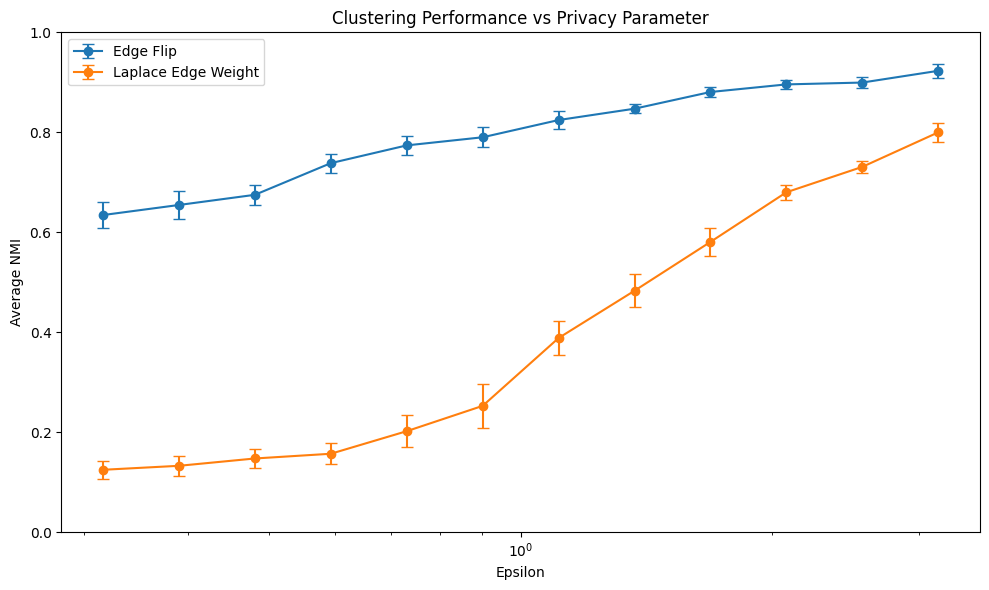

In [9]:
### Plotting NMI

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Clustering Performance vs Privacy Parameter')
plt.legend()
plt.tight_layout()
plt.show()

## Laplace Edge Counts

In [14]:
np.random.seed(0)

## Parameters for the SBM
block_size = 100
num_blocks = 2
sizes = [block_size] * num_blocks
n = block_size * num_blocks

p = 0.15 #1.5*n**(-0.3)
r = 0.15 #0.15*n**(-0.3)
probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

rho = 0.5
intra_mean = 10
inter_mean = intra_mean * rho
means = np.eye(num_blocks) * intra_mean + (1 - np.eye(num_blocks)) * inter_mean

## Parameters for the DP algorithms
epsilon_values = np.logspace(-0.5, 0.5, num=12) 

empty_list = [[] for _ in range(len(epsilon_values))]
results = {
    'Rho = 0.5': copy.deepcopy(empty_list),
    'Rho = 0.25': copy.deepcopy(empty_list),
    'Rho = 0.1': copy.deepcopy(empty_list),
    'Rho = 0.05': copy.deepcopy(empty_list),
    'Rho = 0.01': copy.deepcopy(empty_list)
}

## Parameters for the clustering
n_clusters = num_blocks

## Parameters for the experiments
sample_size = 5

In [15]:
# Test each epsilon value
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")

    for run in range(sample_size):
        seed = run
        np.random.seed(seed)

        #### Generate the SBM graph
        G = get_poisson_SBM(block_size, num_blocks, probs, means)
        A = nx.to_numpy_array(G)
        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)

        #### Evaluate
        
        ### Rho = 0.5
        rho = 0.5
        intra_mean = 10
        inter_mean = intra_mean * rho
        means = np.eye(num_blocks) * intra_mean + (1 - np.eye(num_blocks)) * inter_mean
        G = get_poisson_SBM(block_size, num_blocks, probs, means)
        A = nx.to_numpy_array(G)
        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)
        A_ef = laplace_edge_count(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Rho = 0.5'][idx].append(nmi_score)

        ### Rho = 0.25
        rho = 0.25
        intra_mean = 10
        inter_mean = intra_mean * rho
        means = np.eye(num_blocks) * intra_mean + (1 - np.eye(num_blocks)) * inter_mean
        G = get_poisson_SBM(block_size, num_blocks, probs, means)
        A = nx.to_numpy_array(G)
        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)
        A_ef = laplace_edge_count(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Rho = 0.25'][idx].append(nmi_score)

        ### Rho = 0.1
        rho = 0.1
        intra_mean = 10
        inter_mean = intra_mean * rho
        means = np.eye(num_blocks) * intra_mean + (1 - np.eye(num_blocks)) * inter_mean
        G = get_poisson_SBM(block_size, num_blocks, probs, means)
        A = nx.to_numpy_array(G)
        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)
        A_ef = laplace_edge_count(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Rho = 0.1'][idx].append(nmi_score)

        ### Rho = 0.05
        rho = 0.05
        intra_mean = 10
        inter_mean = intra_mean * rho
        means = np.eye(num_blocks) * intra_mean + (1 - np.eye(num_blocks)) * inter_mean
        G = get_poisson_SBM(block_size, num_blocks, probs, means)
        A = nx.to_numpy_array(G)
        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)
        A_ef = laplace_edge_count(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Rho = 0.05'][idx].append(nmi_score)

        ### Rho = 0.01
        rho = 0.01
        intra_mean = 10
        inter_mean = intra_mean * rho
        means = np.eye(num_blocks) * intra_mean + (1 - np.eye(num_blocks)) * inter_mean
        G = get_poisson_SBM(block_size, num_blocks, probs, means)
        A = nx.to_numpy_array(G)
        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)
        A_ef = laplace_edge_count(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Rho = 0.01'][idx].append(nmi_score)



Testing epsilon = 0.31622776601683794
Testing epsilon = 0.3898603702549073
Testing epsilon = 0.48063808630643906
Testing epsilon = 0.5925530975545678
Testing epsilon = 0.7305271542664454
Testing epsilon = 0.9006280202112786
Testing epsilon = 1.1103363181676378
Testing epsilon = 1.368874509537081
Testing epsilon = 1.6876124757881479
Testing epsilon = 2.080567538217171
Testing epsilon = 2.5650209056800457
Testing epsilon = 3.1622776601683795


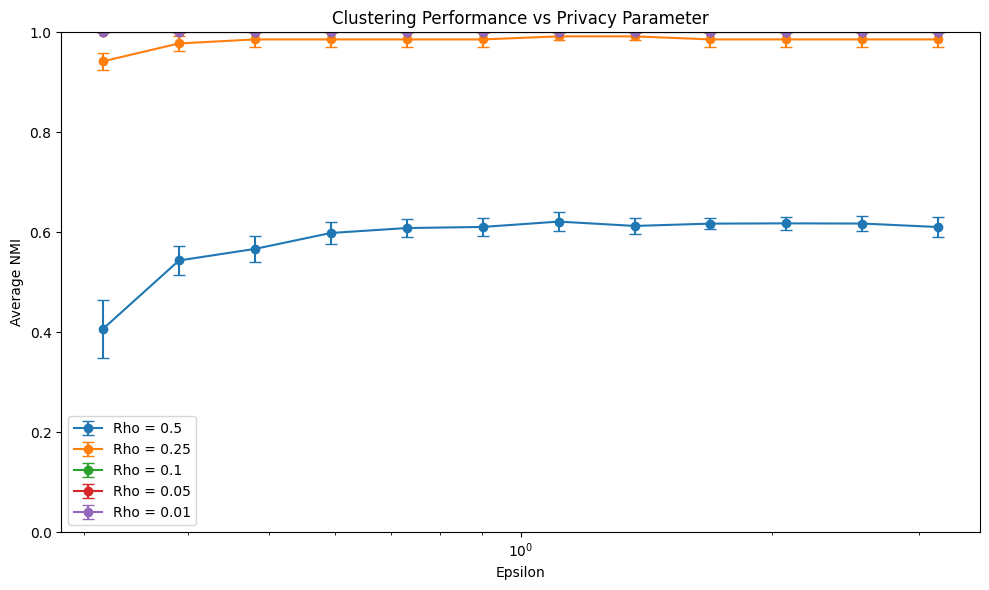

In [16]:
### Plotting NMI

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Clustering Performance vs Privacy Parameter')
plt.legend()
plt.tight_layout()
plt.show()